# TP — Gradient Boosting en pratique : XGBoost et LightGBM

**Jour 2 — chapitre 04 : Data visualisation & méthodes ensemblistes (Gradient Boosting)**

## Mise en situation

Le TP précédent a comparé une régression logistique à un Random Forest (bagging). On
complète ici la comparaison avec deux implémentations optimisées de gradient boosting,
très utilisées en compétition Kaggle (diapo 30) : **XGBoost** et **LightGBM**.


In [1]:
import pandas as pd
import seaborn as sns

titanic_raw = sns.load_dataset("titanic")
titanic = titanic_raw.rename(columns={
    "survived": "Survived",
    "pclass": "Pclass",
    "sex": "Sex",
    "age": "Age",
    "sibsp": "SibSp",
    "parch": "Parch",
    "fare": "Fare",
    "embarked": "Embarked",
})[["Survived", "Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]].copy()

# Nettoyage (TP "valeurs manquantes", notebook 03)
age_median_par_groupe = titanic.groupby(["Sex", "Pclass"])["Age"].transform("median")
titanic["Age"] = titanic["Age"].fillna(age_median_par_groupe).fillna(titanic["Age"].median())
titanic["Embarked"] = titanic["Embarked"].fillna(titanic["Embarked"].mode()[0])

# Feature engineering (TP "feature engineering", notebook 04)
titanic = pd.get_dummies(titanic, columns=["Sex", "Embarked"], drop_first=True)
titanic["FamilySize"] = titanic["SibSp"] + titanic["Parch"] + 1
titanic["IsAlone"] = (titanic["FamilySize"] == 1).astype(int)

titanic = titanic.reset_index(drop=True)
titanic.insert(0, "PassengerId", titanic.index + 1)

features = ["Pclass", "Age", "Fare", "FamilySize", "IsAlone", "Sex_male"]
features = [c for c in features if c in titanic.columns]

X = titanic[features]
y = titanic["Survived"]

X.head()

,Pclass,Age,Fare,FamilySize,IsAlone,Sex_male
0,3,22.0,7.2500,2,0,True
1,1,38.0,71.2833,2,0,False
2,3,26.0,7.9250,1,1,False
3,1,35.0,53.1000,2,0,False
4,3,35.0,8.0500,1,1,True


## Étape 1 — Entraîner XGBoost et LightGBM sur les mêmes features

**Question de réflexion :** XGBoost et LightGBM ont-ils besoin d'un encodage ou d'une
normalisation particuliers, comme vu pour le Random Forest dans le TP précédent ?


In [2]:
from sklearn.model_selection import train_test_split, cross_val_score
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Suivi des expériences avec MLflow

On réutilise ici la même expérience MLflow que dans le TP précédent
(`OFDS - Jour 2 - Titanic`) : les runs de ce TP viendront s'ajouter à ceux de la
régression logistique et du Random Forest déjà enregistrés, pour une comparaison directe
des quatre algorithmes dans la même vue.

Plutôt que de garder une trace manuelle des scores dans un carnet ou un tableur (voir la
check-list du jour 3 : « a-t-on conservé une trace des expériences menées ? »), on utilise
ici **MLflow** pour enregistrer automatiquement les paramètres et les métriques de chaque
essai.

Ceci suppose qu'un serveur de tracking MLflow tourne en local, lancé au préalable avec :

```bash
mlflow server --host 127.0.0.1 --port 5001 \
    --backend-store-uri sqlite:///mlflow_data/mlflow.db \
    --default-artifact-root ./mlflow_data/mlartifacts
```

L'interface est ensuite consultable dans un navigateur à l'adresse
http://127.0.0.1:5001. Voir `demos/README.md` pour le détail, et
`speech/ressources-techniques.md` pour son rôle dans la stack technique.

Si aucun serveur n'est joignable (par exemple sur Kaggle Notebooks ou Colab, qui ne
voient pas votre machine locale), remplacez la ligne `mlflow.set_tracking_uri(...)`
ci-dessous par `mlflow.set_tracking_uri("file:./mlruns")` : MLflow écrit alors ses runs
dans un simple dossier local, consultable plus tard avec `mlflow ui`.


In [3]:
import mlflow
import mlflow.xgboost
import mlflow.lightgbm

mlflow.set_tracking_uri("http://127.0.0.1:5001")
experience = mlflow.set_experiment("OFDS - Jour 2 - Titanic")
print("Expérience MLflow active :", experience.name)

Expérience MLflow active : OFDS - Jour 2 - Titanic


In [4]:
xgb = XGBClassifier(
    n_estimators=300, max_depth=3, learning_rate=0.05,
    random_state=42, eval_metric="logloss",
)
lgbm = LGBMClassifier(
    n_estimators=300, max_depth=3, learning_rate=0.05,
    random_state=42, verbose=-1,
)

with mlflow.start_run(run_name="xgboost"):
    scores_xgb = cross_val_score(xgb, X_train, y_train, cv=5)
    mlflow.log_param("model", "XGBClassifier")
    mlflow.log_param("n_estimators", 300)
    mlflow.log_param("max_depth", 3)
    mlflow.log_param("learning_rate", 0.05)
    mlflow.log_metric("cv_accuracy_mean", scores_xgb.mean())

with mlflow.start_run(run_name="lightgbm"):
    scores_lgbm = cross_val_score(lgbm, X_train, y_train, cv=5)
    mlflow.log_param("model", "LGBMClassifier")
    mlflow.log_param("n_estimators", 300)
    mlflow.log_param("max_depth", 3)
    mlflow.log_param("learning_rate", 0.05)
    mlflow.log_metric("cv_accuracy_mean", scores_lgbm.mean())

print("XGBoost — score moyen CV :", round(scores_xgb.mean(), 3))
print("LightGBM — score moyen CV :", round(scores_lgbm.mean(), 3))

View run xgboost at: http://127.0.0.1:5001/#/experiments/1/runs/ce084deb395c4b2ab37f838a0b912ef0
View experiment at: http://127.0.0.1:5001/#/experiments/1


View run lightgbm at: http://127.0.0.1:5001/#/experiments/1/runs/f4c95929e7a7400b91c8e183b60f3ac1
View experiment at: http://127.0.0.1:5001/#/experiments/1
XGBoost — score moyen CV : 0.833
LightGBM — score moyen CV : 0.831


**Ce qu'on observe** : comme le Random Forest, XGBoost et LightGBM n'ont besoin ni
d'encodage particulier ni de normalisation — ce sont des méthodes à base d'arbres,
insensibles à l'échelle des variables. Ouvrez http://127.0.0.1:5001, expérience
« OFDS - Jour 2 - Titanic » : les quatre runs (régression logistique, Random Forest,
XGBoost, LightGBM) sont désormais comparables côte à côte sur la même métrique.


## Étape 2 — Gestion native des valeurs manquantes

**Question de réflexion :** que se passe-t-il si on entraîne la régression logistique
des notebooks précédents sans imputer l'âge manquant ? Et avec XGBoost ou LightGBM ?

*Note : selon la version de scikit-learn installée, `RandomForestClassifier` peut
désormais aussi accepter des valeurs manquantes nativement (support ajouté dans des
versions récentes) — ce n'est donc plus un bon exemple de contraste. Les modèles
linéaires comme la régression logistique, eux, l'exigent toujours : c'est un exemple
plus robuste dans le temps.*


In [5]:
# On repart des colonnes brutes, sans l'etape d'imputation de l'age (notebook 03)
titanic_brut = titanic_raw.rename(columns={
    "survived": "Survived", "pclass": "Pclass", "sex": "Sex", "age": "Age",
    "sibsp": "SibSp", "parch": "Parch", "fare": "Fare", "embarked": "Embarked",
})[["Survived", "Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]].copy()

titanic_brut = pd.get_dummies(titanic_brut, columns=["Sex", "Embarked"], drop_first=True)
titanic_brut["FamilySize"] = titanic_brut["SibSp"] + titanic_brut["Parch"] + 1
titanic_brut["IsAlone"] = (titanic_brut["FamilySize"] == 1).astype(int)

features_brut = [c for c in features if c in titanic_brut.columns]
X_brut = titanic_brut[features_brut]
y_brut = titanic_brut["Survived"]

print("Valeurs manquantes dans Age (non imputé) :", X_brut["Age"].isnull().sum())

X_train_brut, X_test_brut, y_train_brut, y_test_brut = train_test_split(
    X_brut, y_brut, test_size=0.2, random_state=42
)

Valeurs manquantes dans Age (non imputé) : 177


In [6]:
from sklearn.linear_model import LogisticRegression

try:
    LogisticRegression(max_iter=5000).fit(X_train_brut, y_train_brut)
except ValueError as erreur:
    print("Échec attendu avec la régression logistique sur des valeurs manquantes :")
    print(erreur)

Échec attendu avec la régression logistique sur des valeurs manquantes :
Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values


In [7]:
with mlflow.start_run(run_name="xgboost_sans_imputation"):
    scores_xgb_brut = cross_val_score(
        XGBClassifier(n_estimators=300, max_depth=3, learning_rate=0.05,
                       random_state=42, eval_metric="logloss"),
        X_train_brut, y_train_brut, cv=5,
    )
    mlflow.log_param("model", "XGBClassifier_sans_imputation")
    mlflow.log_metric("cv_accuracy_mean", scores_xgb_brut.mean())

with mlflow.start_run(run_name="lightgbm_sans_imputation"):
    scores_lgbm_brut = cross_val_score(
        LGBMClassifier(n_estimators=300, max_depth=3, learning_rate=0.05,
                        random_state=42, verbose=-1),
        X_train_brut, y_train_brut, cv=5,
    )
    mlflow.log_param("model", "LGBMClassifier_sans_imputation")
    mlflow.log_metric("cv_accuracy_mean", scores_lgbm_brut.mean())

print("XGBoost (Age non imputé) — score moyen CV :", round(scores_xgb_brut.mean(), 3))
print("LightGBM (Age non imputé) — score moyen CV :", round(scores_lgbm_brut.mean(), 3))

View run xgboost_sans_imputation at: http://127.0.0.1:5001/#/experiments/1/runs/67867390f437418b96fa036b6a4efb66
View experiment at: http://127.0.0.1:5001/#/experiments/1


View run lightgbm_sans_imputation at: http://127.0.0.1:5001/#/experiments/1/runs/ae38256ceae44709bd5280f76c07975b
View experiment at: http://127.0.0.1:5001/#/experiments/1
XGBoost (Age non imputé) — score moyen CV : 0.83
LightGBM (Age non imputé) — score moyen CV : 0.824


**Ce qu'on observe** : la régression logistique lève une `ValueError` (« Input X
contains NaN ») — comme tout modèle linéaire, elle exige une imputation préalable,
qui était donc indispensable au TP précédent. XGBoost et LightGBM, eux, s'entraînent
directement sur les valeurs manquantes, avec un score très proche de la version
imputée : ils apprennent, pour chaque split, la meilleure direction par défaut à donner
aux observations manquantes, plutôt que de nécessiter une imputation en amont. C'est un
avantage concret en compétition Kaggle, où le nettoyage des valeurs manquantes est
rarement trivial.


## Étape 3 — Importance des features

**Question de réflexion :** l'ordre d'importance des features obtenu avec XGBoost est-il
cohérent avec celui du Random Forest (TP précédent) ?


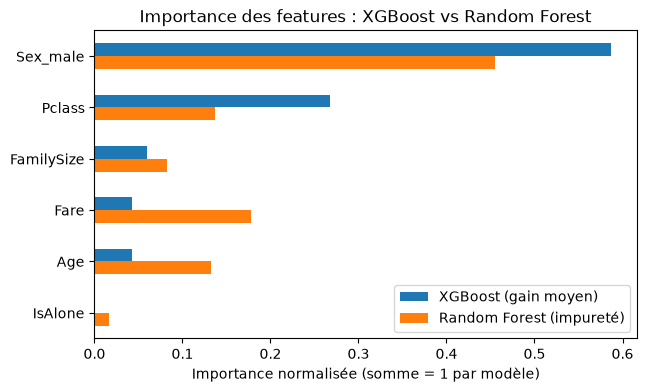

,XGBoost (gain moyen),Random Forest (impureté)
Sex_male,0.587,0.455
Pclass,0.268,0.136
FamilySize,0.059,0.082
Fare,0.043,0.178
Age,0.043,0.133
IsAlone,0.000,0.016


In [8]:
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

xgb.fit(X_train, y_train)
importances_xgb = pd.Series(xgb.feature_importances_, index=X.columns)

# Meme Random Forest que dans le TP precedent, pour comparer les deux classements
rf = RandomForestClassifier(n_estimators=300, max_depth=5, random_state=42)
rf.fit(X_train, y_train)
importances_rf = pd.Series(rf.feature_importances_, index=X.columns)

comparaison_importances = pd.DataFrame({
    "XGBoost (gain moyen)": importances_xgb,
    "Random Forest (impureté)": importances_rf,
}).sort_values("XGBoost (gain moyen)", ascending=False)

fig_importances, ax = plt.subplots(figsize=(7, 4))
comparaison_importances.plot(kind="barh", ax=ax)
ax.set_title("Importance des features : XGBoost vs Random Forest")
ax.set_xlabel("Importance normalisée (somme = 1 par modèle)")
ax.invert_yaxis()
plt.show()

comparaison_importances.round(3)

**Ce qu'on observe** : les deux modèles placent `Sex_male` nettement en tête, mais la suite
du classement diffère. XGBoost met `Pclass` en deuxième position et relègue `Age` et `Fare`
en fin de classement (seul `IsAlone`, quasi nul, est derrière), alors que le Random Forest
place `Fare` en deuxième position, devant `Pclass` et `Age`.

Ce n'est pas une contradiction : les deux mesures ne calculent pas la même chose.
L'importance par défaut de XGBoost est le **gain moyen** par split : une variable comme
`Fare`, utilisée dans beaucoup de splits qui améliorent chacun peu le modèle, obtient un gain
moyen faible. Le Random Forest **cumule** la baisse d'impureté sur tous les splits, ce qui
favorise les variables continues comme `Fare` ou `Age`, qui offrent beaucoup de seuils de
découpe possibles.

À retenir : une importance de features dépend du modèle et de la mesure utilisée. Seul le
signal commun aux différents modèles (ici, le sexe) est vraiment robuste ; pour une mesure
indépendante du modèle, on peut se tourner vers `sklearn.inspection.permutation_importance`.

## Étape 4 — Soumission avec le meilleur des deux modèles

**Question de réflexion :** comment décider objectivement, entre XGBoost et LightGBM,
lequel utiliser pour la soumission Kaggle ?


In [9]:
from sklearn.metrics import accuracy_score

meilleur_nom = "xgboost" if scores_xgb.mean() >= scores_lgbm.mean() else "lightgbm"
meilleur_modele = xgb if meilleur_nom == "xgboost" else lgbm
log_model_fn = mlflow.xgboost.log_model if meilleur_nom == "xgboost" else mlflow.lightgbm.log_model

with mlflow.start_run(run_name=f"{meilleur_nom}_final"):
    meilleur_modele.fit(X_train, y_train)
    predictions = meilleur_modele.predict(X_test)
    test_accuracy = accuracy_score(y_test, predictions)

    submission = pd.DataFrame({
        "PassengerId": titanic.loc[X_test.index, "PassengerId"],
        "Survived": predictions,
    })
    submission.to_csv("submission_gradient_boosting.csv", index=False)

    mlflow.log_param("model", meilleur_nom)
    mlflow.log_metric("test_accuracy", test_accuracy)
    # mlflow.sklearn.log_model() ne convient pas ici : XGBoost/LightGBM ont leur propre
    # format natif de serialisation, plus fiable que le pickle generique sklearn.
    log_model_fn(meilleur_modele, name="model")
    mlflow.log_figure(fig_importances, "feature_importance.png")
    mlflow.log_artifact("submission_gradient_boosting.csv")

print(f"Modèle retenu : {meilleur_nom} — accuracy sur notre jeu de test local :", round(test_accuracy, 3))
submission.head()

View run xgboost_final at: http://127.0.0.1:5001/#/experiments/1/runs/318d8125abe04fc1ac9527904a3dc159
View experiment at: http://127.0.0.1:5001/#/experiments/1
Modèle retenu : xgboost — accuracy sur notre jeu de test local : 0.81


,PassengerId,Survived
709,710,0
439,440,0
840,841,0
720,721,1
39,40,1


**Ce qu'on observe** : on choisit le modèle sur la base du score de cross-validation
(plus stable), pas d'un score unique — même logique que la check-list du jour 3
(« se fier avant tout à son propre score de cross-validation »).

**À retenir pour le débriefing du TP** : ouvrez http://127.0.0.1:5001, expérience
« OFDS - Jour 2 - Titanic ». Elle réunit maintenant régression logistique, Random Forest,
XGBoost et LightGBM, avec et sans imputation — de quoi discuter en groupe l'arbitrage
entre performance, simplicité d'implémentation, et tolérance aux valeurs manquantes.

Bagging et boosting assemblent tous deux des arbres, mais différemment : le Random Forest
(bagging) les entraîne indépendamment et moyenne leurs prédictions, alors que XGBoost et
LightGBM (boosting) les enchaînent, chaque nouvel arbre étant entraîné sur l'erreur résiduelle
du modèle courant (schéma « modèle initial → résidu → nouvel arbre → mise à jour », diapo 30).
Le jour 3, le TP bonus de stacking/blending montre une troisième façon de combiner des
modèles : partir de modèles de nature différente (régression logistique, Random Forest,
gradient boosting), puis moyenner leurs prédictions (blending) ou confier à un méta-modèle
le soin de les pondérer (stacking).